# **Objective of This Notebook**
This notebook summarises and interprets the final results of the Spotify popularity prediction project. The objective is to critically evaluate model performance, identify key predictive patterns, discuss practical implications, and reflect on limitations and opportunities for future improvement.

# **1. Imports and Config**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
from IPython.display import Image, display


### **1.1 Paths**

In [2]:
# Detect project root
PROJECT_ROOT = Path.cwd().parent

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
EDA_FIGURES_PATH = FIGURES_PATH / "eda"
TABLES_PATH = PROJECT_ROOT / "outputs" / "tables"
MODELS_PATH = PROJECT_ROOT / "outputs" / "models"

print("Project root:", PROJECT_ROOT)
print("EDA figures path:", EDA_FIGURES_PATH)
print("Tables path:", TABLES_PATH)
print("Models path:", MODELS_PATH)

Project root: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction
EDA figures path: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\outputs\figures\eda
Tables path: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\outputs\tables
Models path: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\outputs\models


### **1.2 Helper function**

In [3]:
#tThis function helps display figures if it exists in the directory
def show_figure(filename, folder=None, width=850):

    if folder is None:
        folder = FIGURES_PATH

    figure_path = folder / filename

    if figure_path.exists():
        display(Image(filename=str(figure_path), width=width))
    else:
        print(f"Figure not found: {figure_path}")

### **1.3 Loading Outputs**

In [4]:
# Load model comparison table
results_df = pd.read_csv(TABLES_PATH / "model_comparison_results.csv")

# Load cleaned dataset
df = pd.read_csv(PROCESSED_PATH / "featured_df.csv")

# Load saved best model
best_model = joblib.load(MODELS_PATH / "best_popularity_model.pkl")

print("Cleaned dataset shape:", df.shape)
results_df

Cleaned dataset shape: (89740, 133)


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,11.789547,11.917845,16.480391,16.650752,0.358266,0.347347
1,Ridge Regression,11.789575,11.917869,16.480391,16.650747,0.358265,0.347348
2,Random Forest,3.710470,9.702097,5.917532,14.596554,0.917263,0.498449
3,Gradient Boosting,13.930028,14.086765,17.437702,17.649048,0.281546,0.266742


# **2. Model Evaluation**

The modelling stage compared four supervised regression models against a dummy baseline. The purpose of the baseline model was to establish a minimum benchmark by predicting the average popularity value for every track.

The trained models all outperformed the dummy baseline, indicating that the dataset contains meaningful predictive signal. However, performance varied across model families. Linear Regression and Ridge Regression achieved similar results, suggesting that the relationship between the available features and popularity is only partially linear.

In [5]:
results_df.sort_values("Test RMSE")

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Random Forest,3.710470,9.702097,5.917532,14.596554,0.917263,0.498449
1,Ridge Regression,11.789575,11.917869,16.480391,16.650747,0.358265,0.347348
0,Linear Regression,11.789547,11.917845,16.480391,16.650752,0.358266,0.347347
3,Gradient Boosting,13.930028,14.086765,17.437702,17.649048,0.281546,0.266742


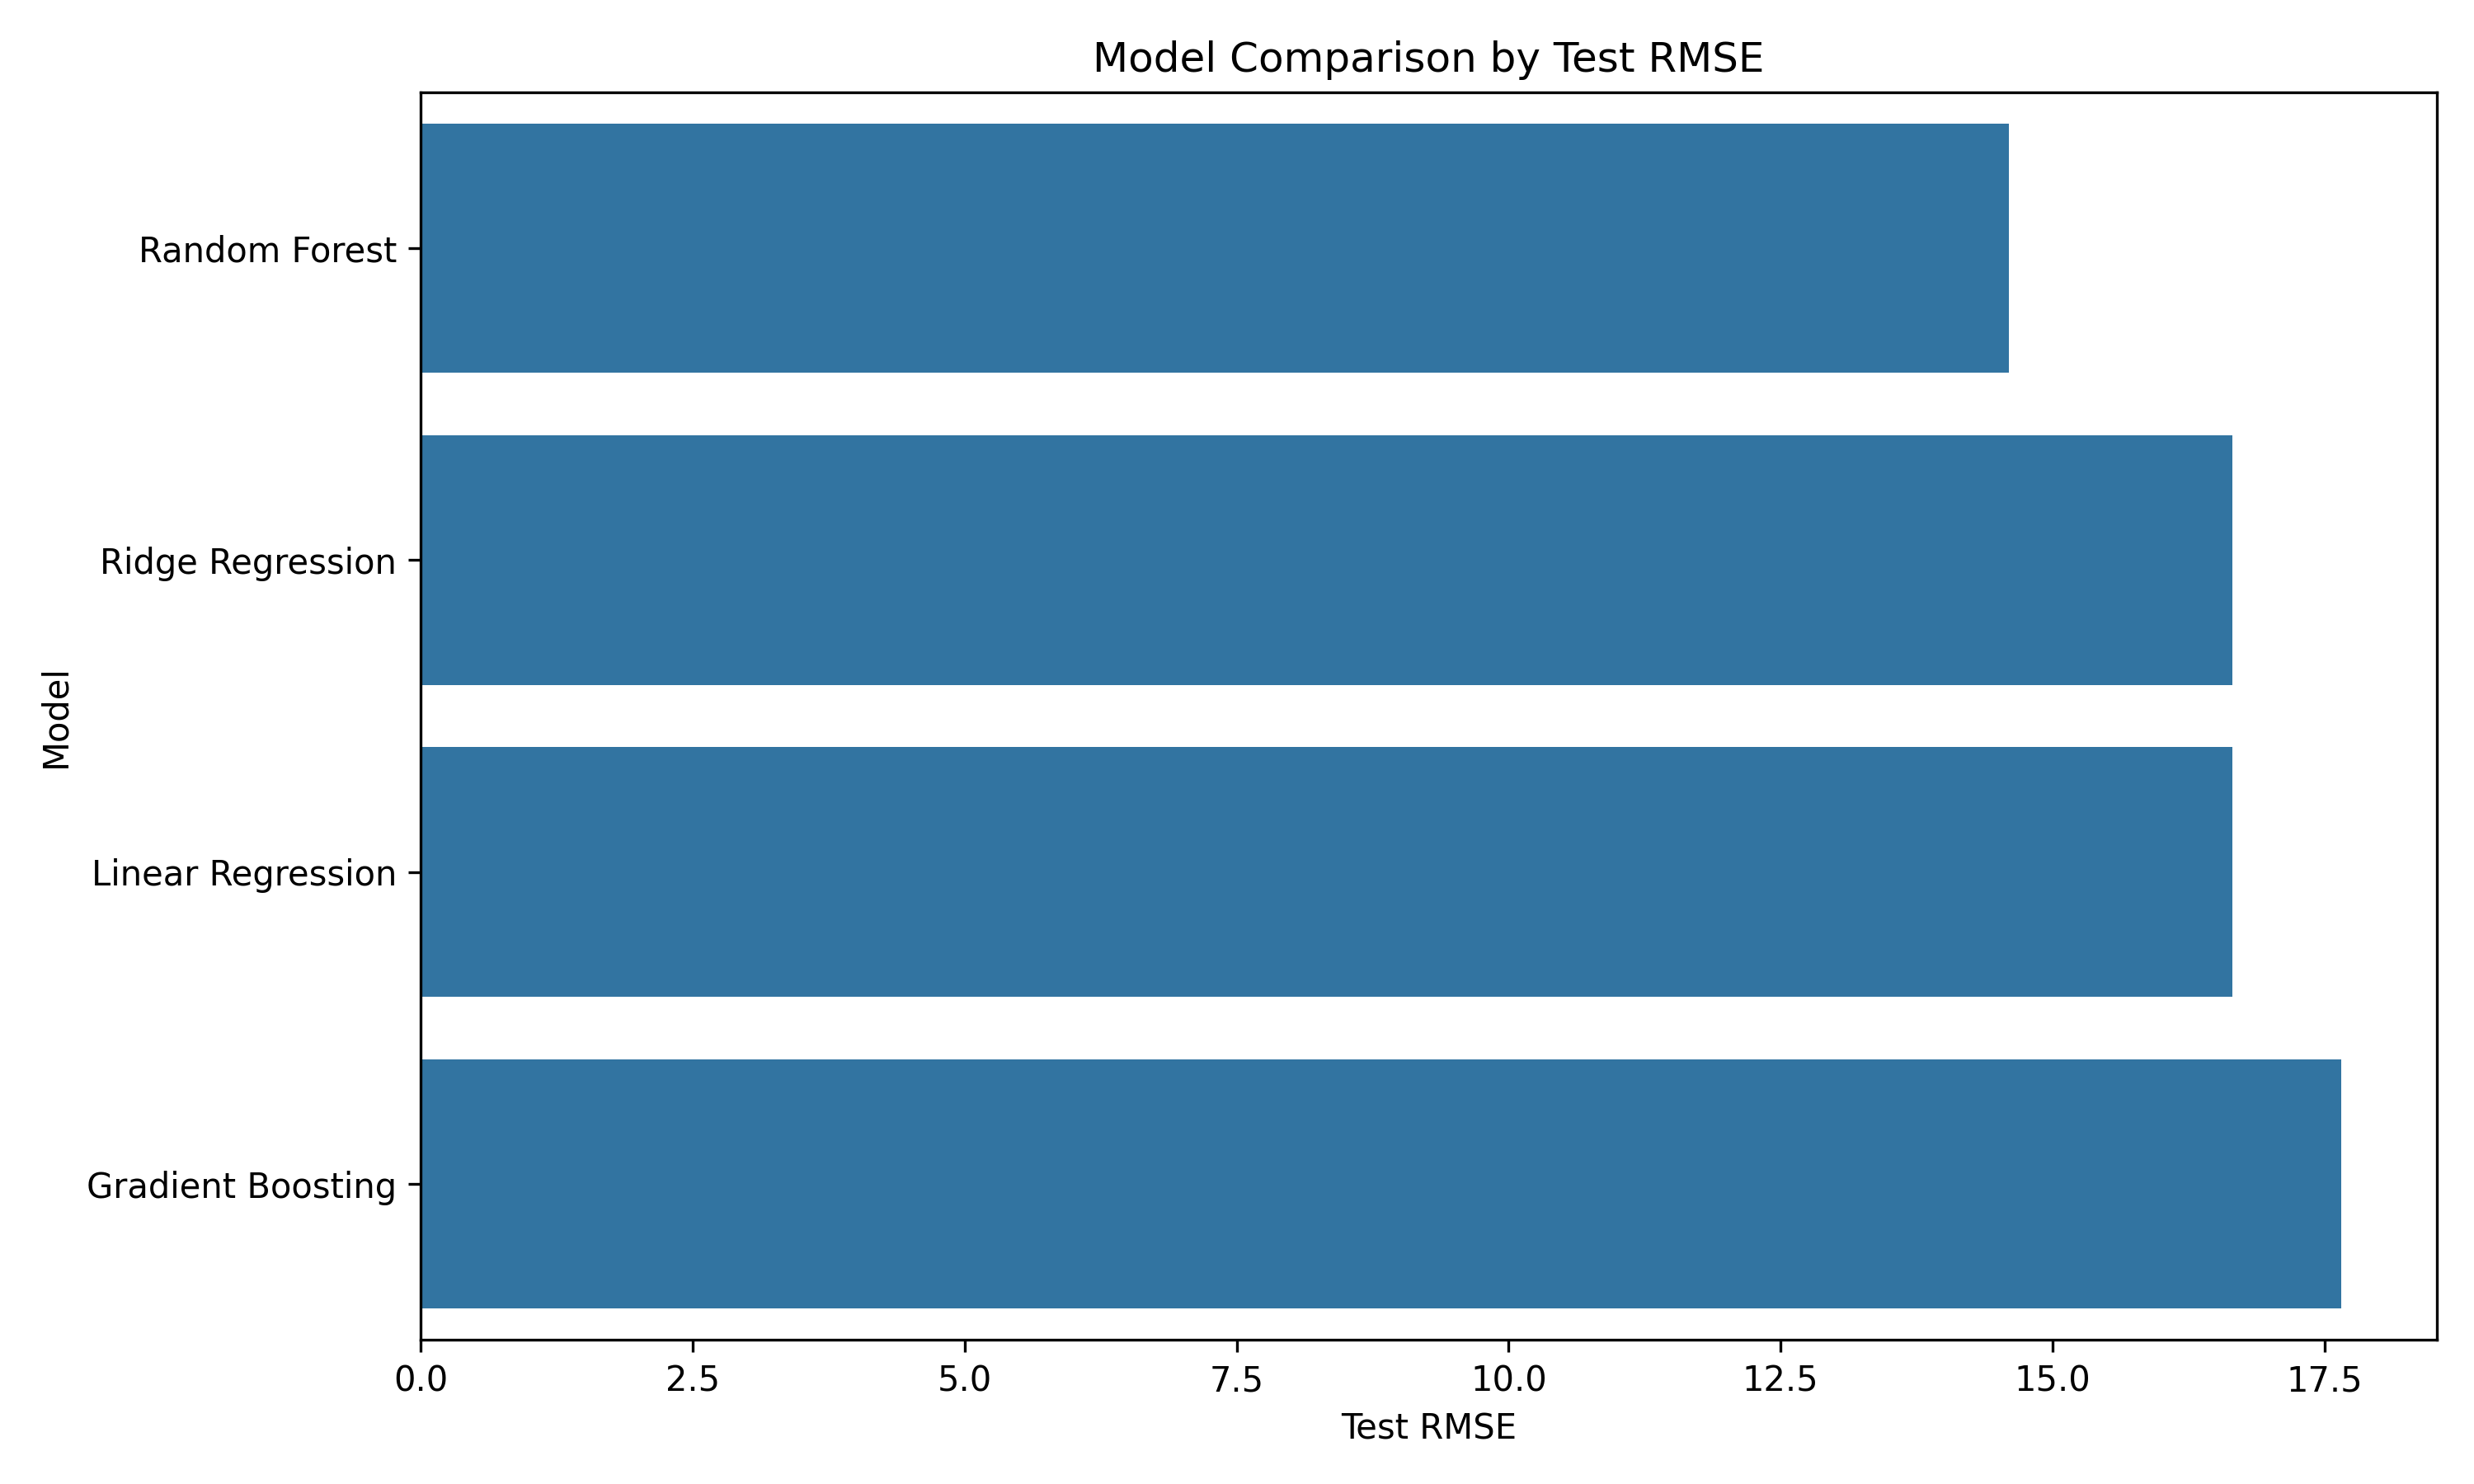

In [6]:
show_figure("model_comparison_rmse.png",folder=MODELS_PATH)

The Random Forest model achieved the strongest predictive performance. Its test R² of approximately 0.50 indicates that around half of the variance in popularity can be explained by the available features. This is a meaningful result given that music popularity is strongly influenced by external factors that are not available in the dataset, such as artist reputation, playlist placement, marketing exposure, release timing, and social media virality.

The performance gap between the Random Forest model and the linear models suggests that non-linear modelling approaches are better suited to this prediction task.

### **2.1 Actual vs Predicted**

The actual versus predicted plot provides a visual assessment of how closely the best model's predictions align with real popularity values.

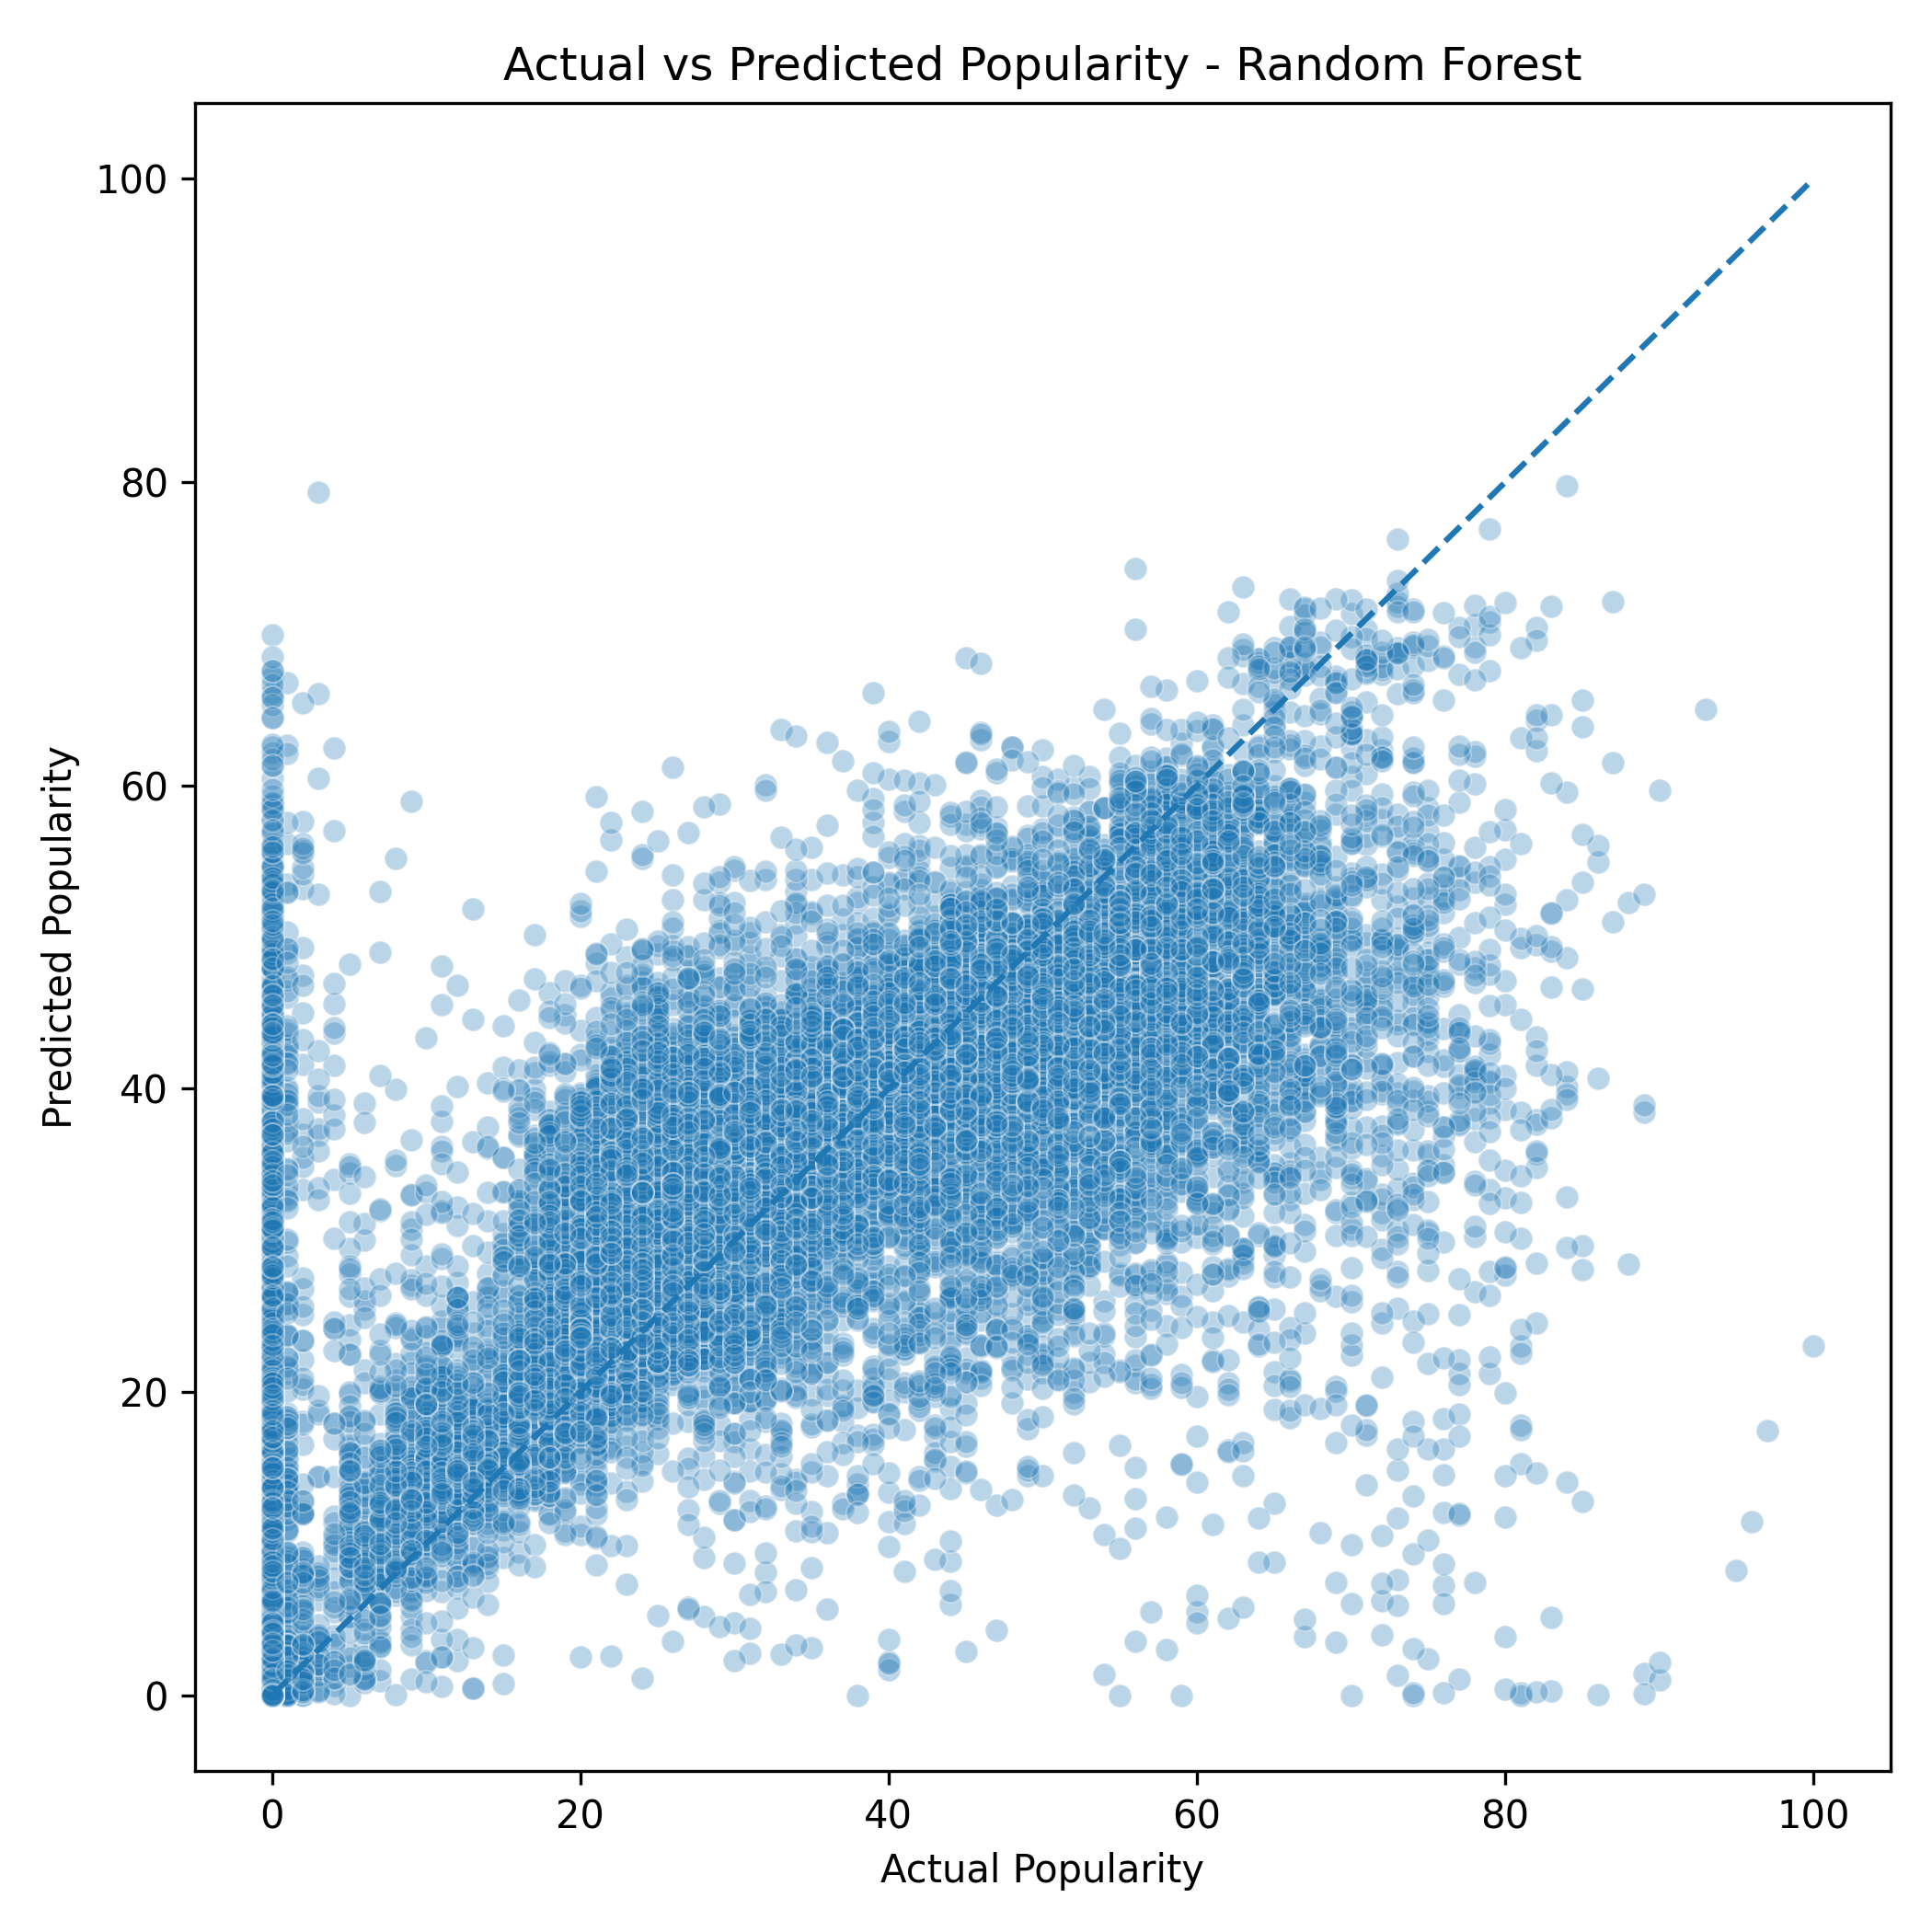

In [7]:
show_figure("actual_vs_predicted.png",folder=MODELS_PATH)

The plot shows a clear positive relationship between actual and predicted popularity, confirming that the model captures meaningful patterns in the data. However, the predictions are compressed toward the middle of the popularity scale. This indicates that the model tends to underpredict very popular tracks and overpredict some low-popularity tracks. This behaviour is common in regression problems where extreme values are harder to predict, especially when important external drivers of popularity are not included in the dataset.

### **2.2 Residual Distribution**

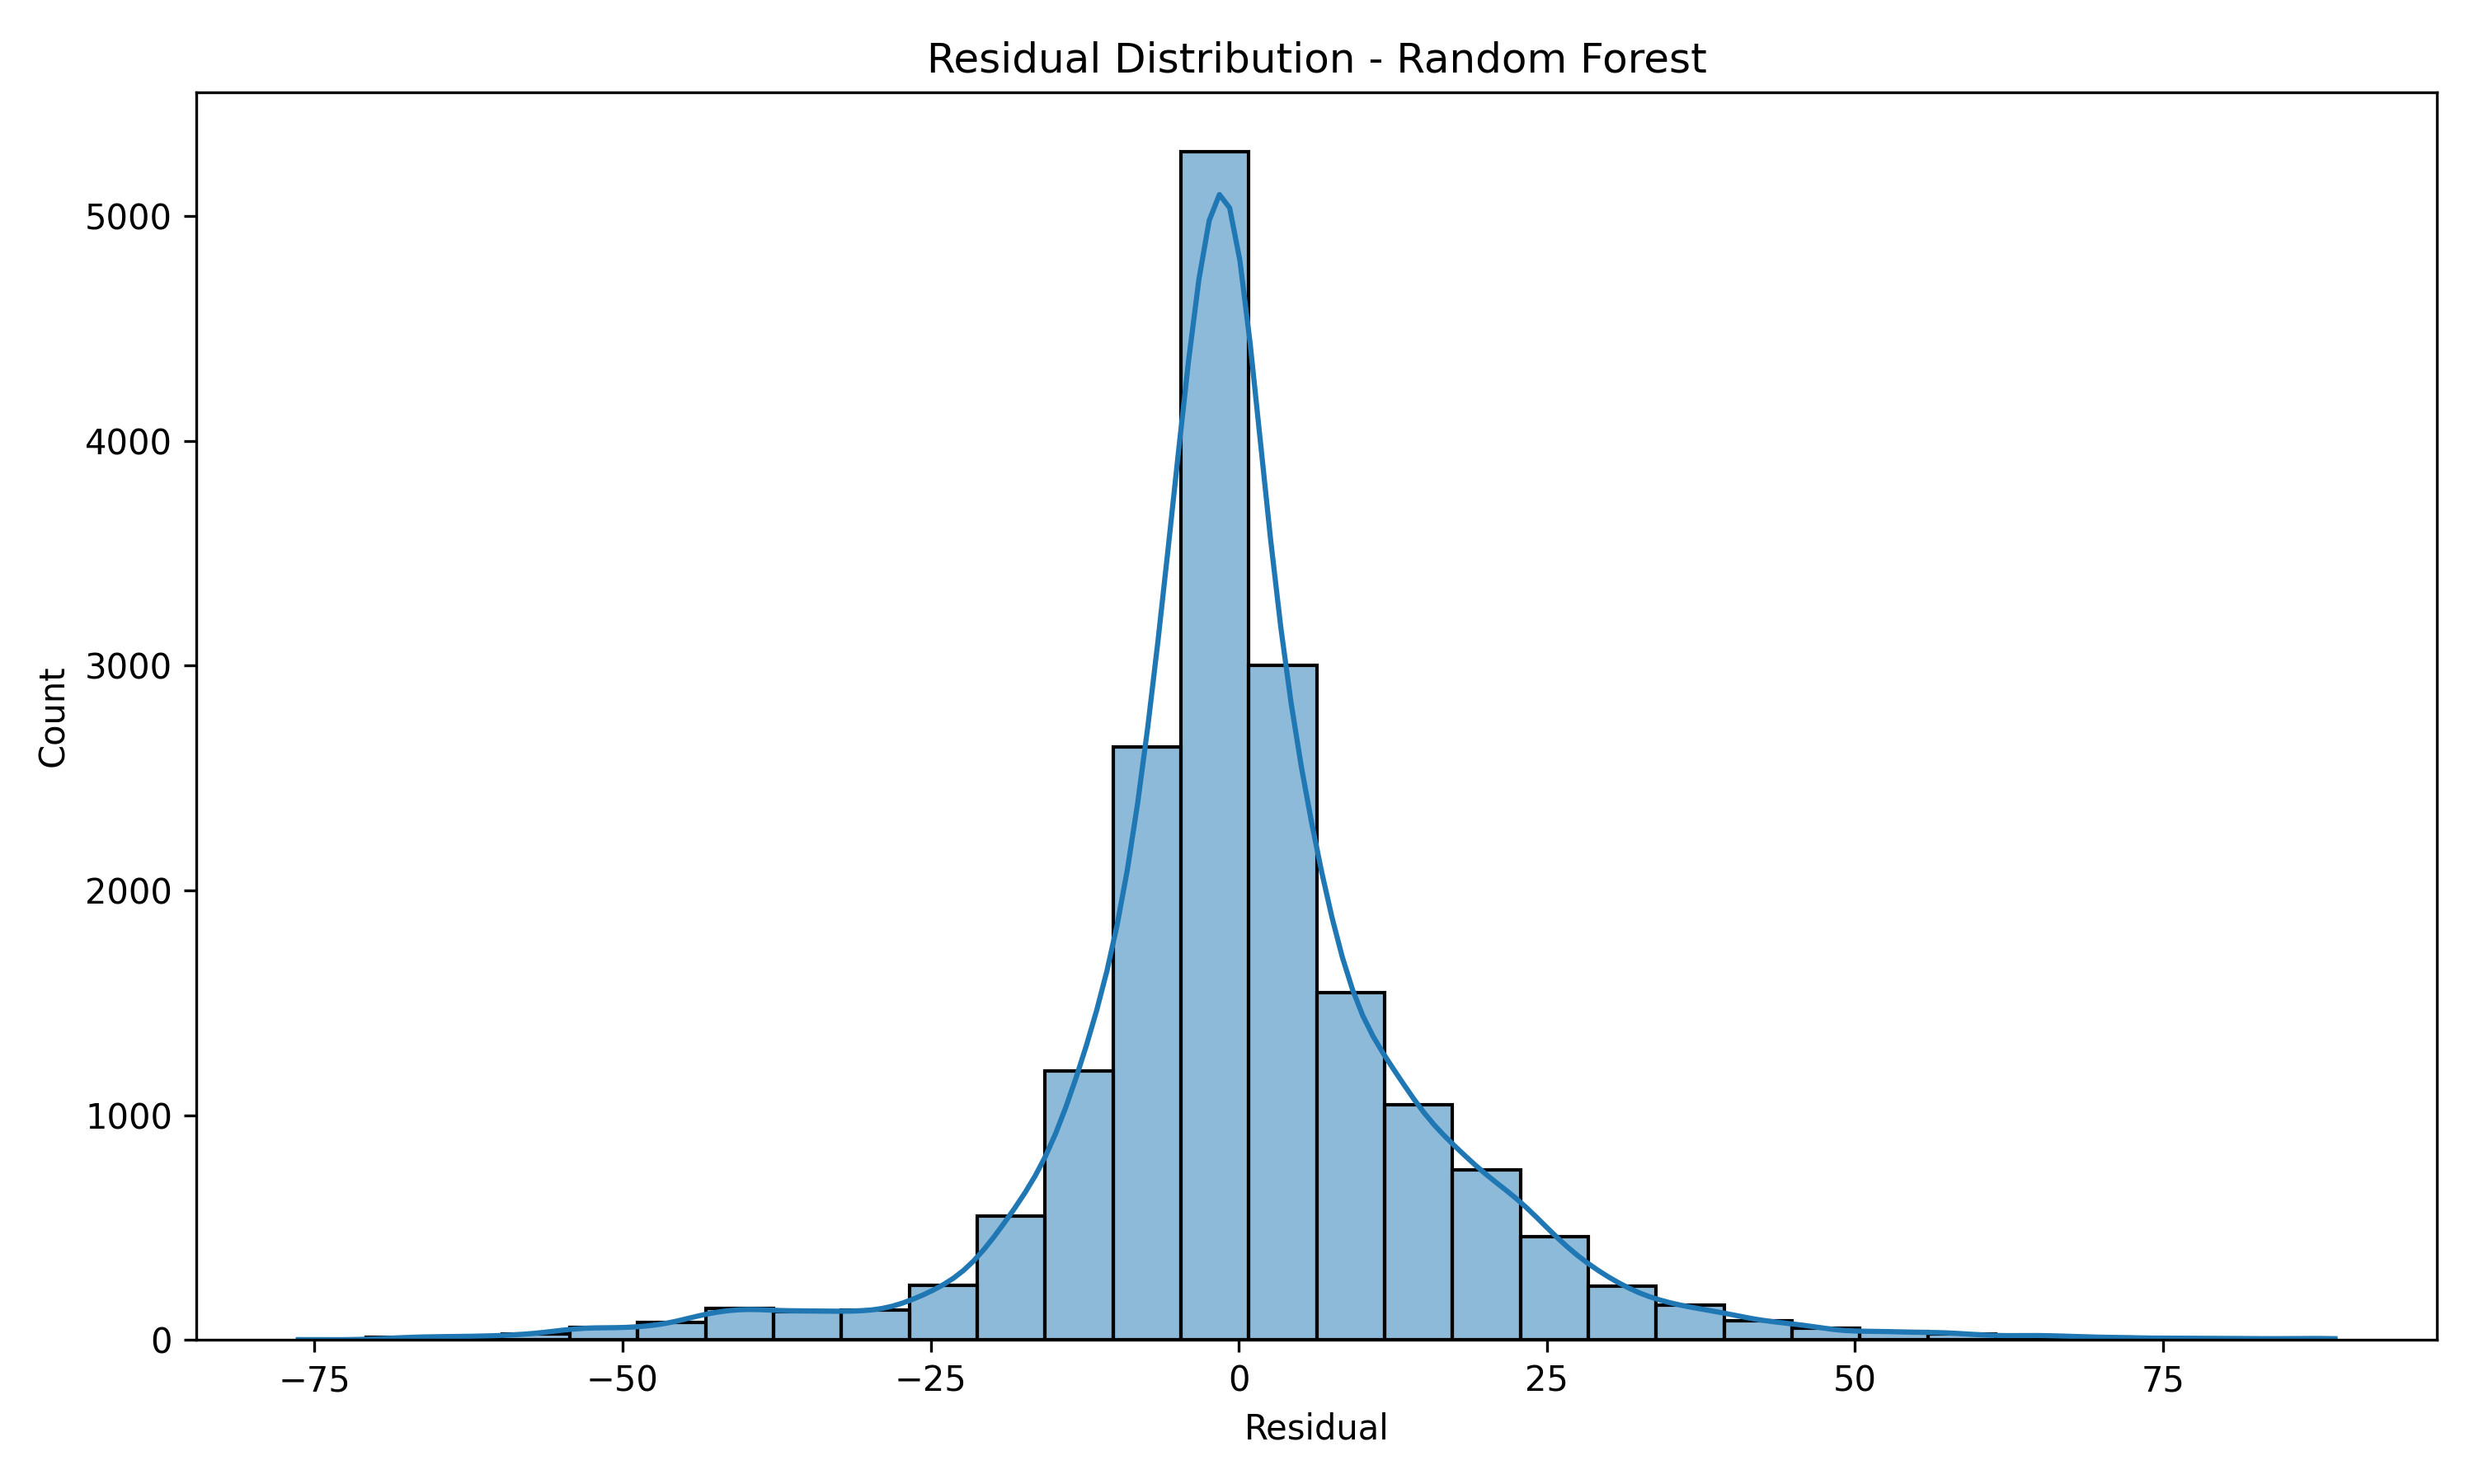

In [8]:
show_figure("residual_distribution.png",folder=MODELS_PATH)

The residual distribution is centred around zero, suggesting that the model does not show severe systematic bias overall. Most prediction errors are relatively small, although the distribution includes heavy tails. These larger errors likely correspond to tracks whose popularity is shaped by factors outside the audio and genre features available in the dataset.

### **2.3 Feature Importance**

Feature importance was extracted from the Random Forest model to understand which variables contributed most strongly to the prediction of popularity.

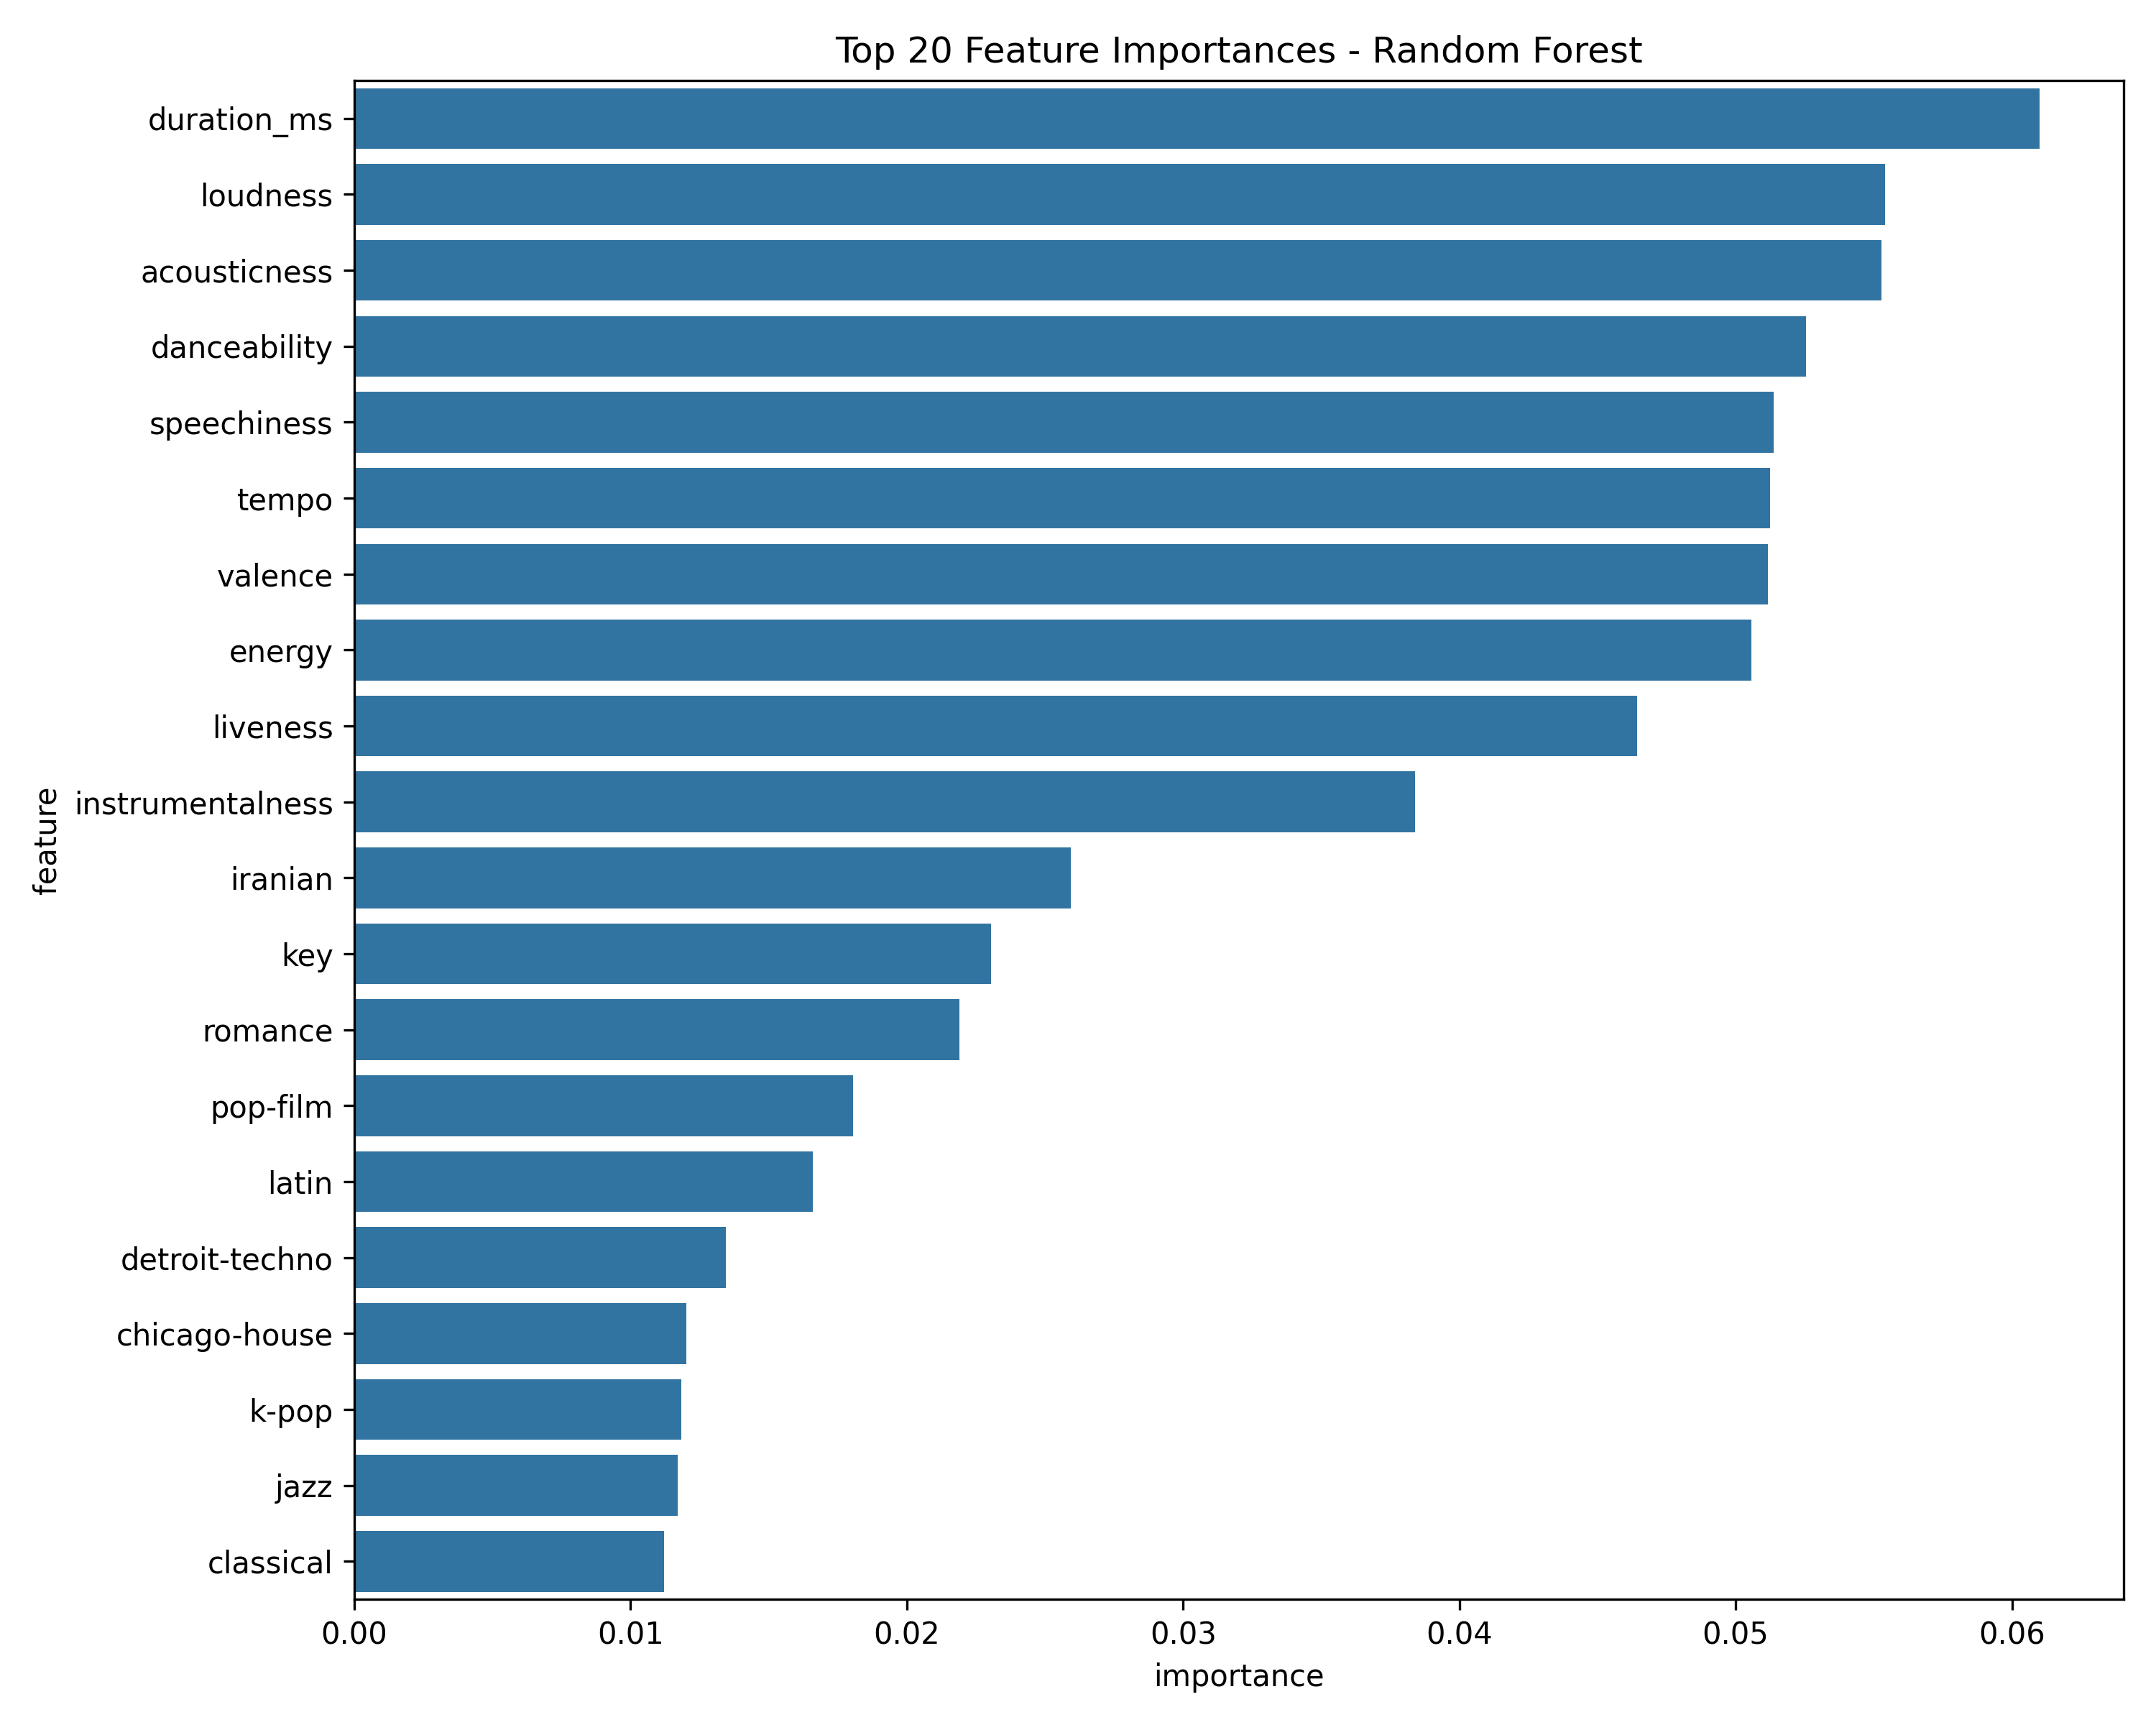

In [9]:
show_figure("feature_importance.png",folder=MODELS_PATH)

The most important predictors include duration, acousticness, loudness, danceability, valence, speechiness, energy, tempo, liveness, and instrumentalness. This most likely means that popularity is not determined by a single musical attribute, but rather by a combination of different characteristics.

`duration_ms` came up at the most important feature. The below chart showed that most tracks are concentrated around typical song lengths of approximately three to four minutes, although some long-duration outliers exist. This suggests that duration may help distinguish mainstream song structures from more niche or long-form audio content, like podcasts or the 'music to study and sleep' genre. The importance of loudness, danceability, energy, and valence is also musically intuitive, as these features are closely related to commercial production style and listener engagement. Meanwhile, instrumentalness had a negative relationship with popularity in earlier correlation analysis, suggesting that heavily instrumental tracks may generally be less mainstream.

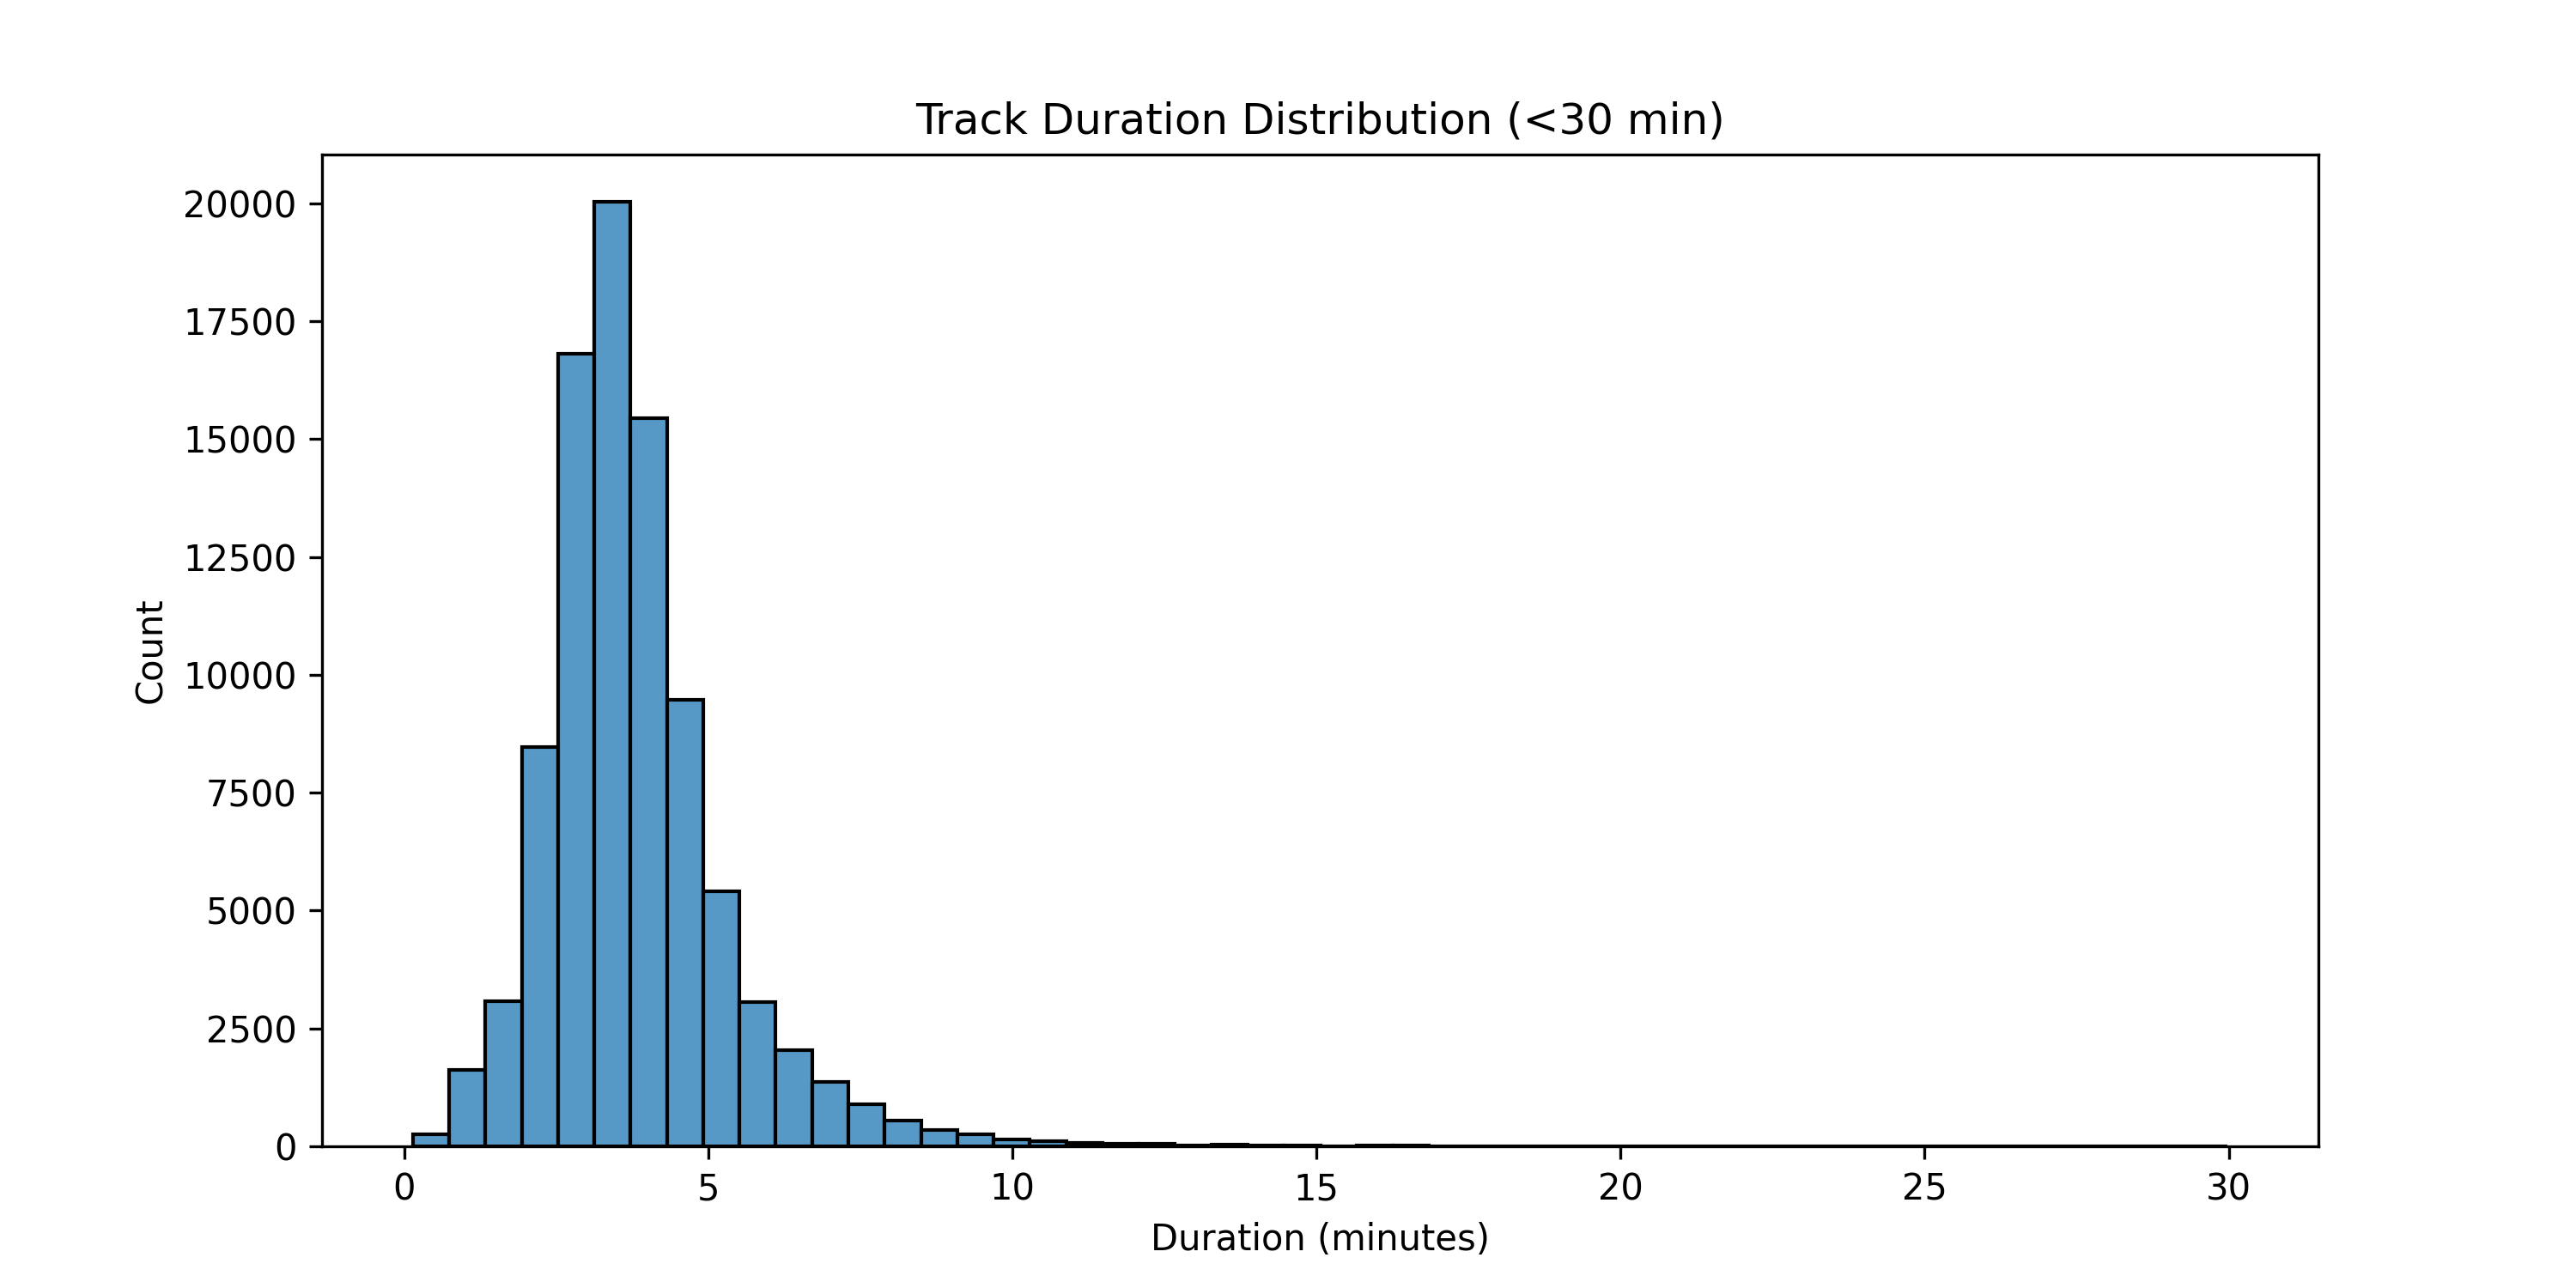

In [10]:
show_figure("track_duration_distribution.png",folder=MODELS_PATH)

### **2.4 Error Analysis**

Additional analysis was performed to evaluate how prediction accuracy varies across different popularity ranges. The results show that the model performs reasonably well for low and medium-popularity tracks, with the lowest average prediction error occurring in the 21–40 popularity range.However, prediction error increases substantially for highly popular tracks. Songs within the 61–80 and especially the 81–100 popularity ranges exhibited considerably larger prediction errors compared to the rest of the dataset. This suggests that extremely popular songs are more difficult to predict using audio and genre features alone. While the model successfully captures general musical patterns associated with popularity, highly successful tracks are likely influenced by additional external factors not represented in the dataset. These may include artist reputation, marketing campaigns, playlist placement, social media virality, cultural trends, and listener behaviour.

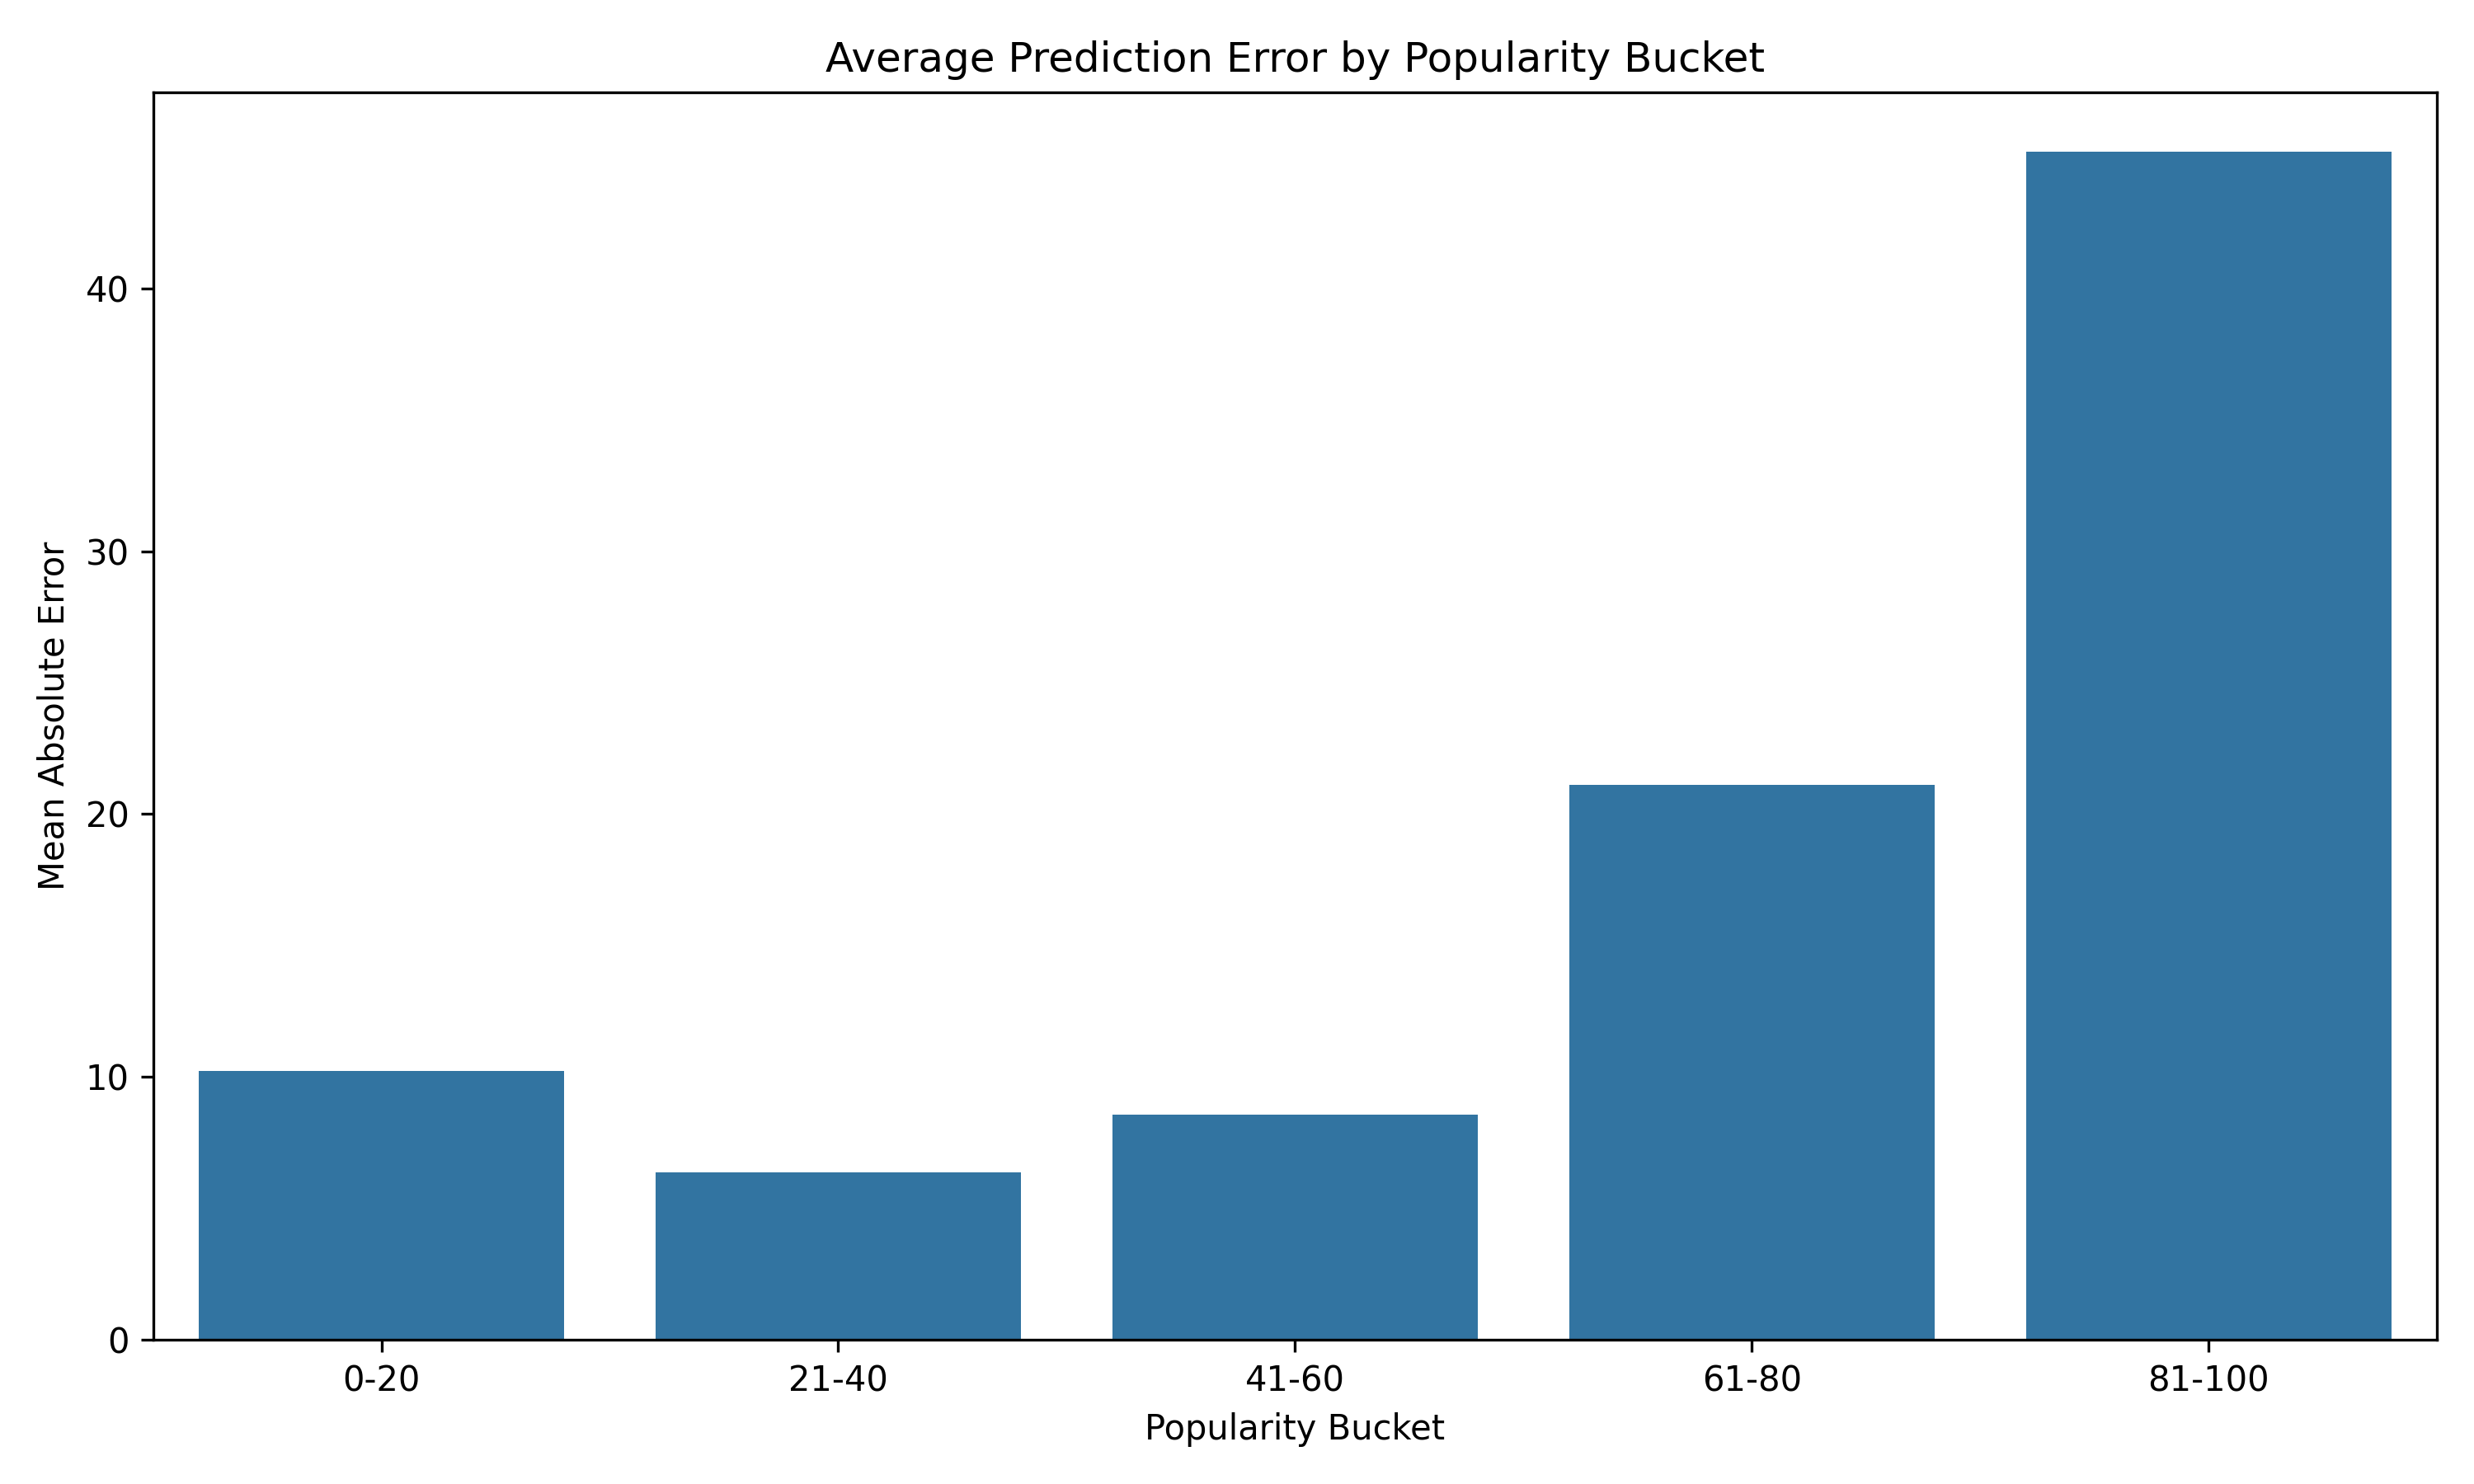

In [11]:
#popularity_bucket_error.png
show_figure("popularity_bucket_error.png",folder=FIGURES_PATH)

# **Limitations**

The most significant limitation is the absence of external variables that strongly influence music popularity. The dataset primarily contains intrinsic audio characteristics and genre information, but does not include factors such as artist reputation, playlist placement, marketing exposure, release timing, social media virality, listener demographics, or broader cultural trends. These external influences likely explain a substantial proportion of the remaining unexplained variance in popularity scores.

Another limitation relates to the structure of the dataset itself. During the exploratory analysis phase, it was discovered that many tracks appeared multiple times under different genre labels. While this issue was addressed through aggregation and genre consolidation, the original dataset organisation may still affect representativeness and genre distribution patterns.

Additionally, popularity is a highly dynamic and socially influenced metric. Listener preferences evolve over time, and trends within the music industry can change rapidly. As a result, the relationships learned by the models may not generalise equally well across different time periods or future musical trends.

The project also relies exclusively on tabular Spotify audio features rather than raw audio signals. While these engineered features provide meaningful information, they cannot fully capture the complexity of musical composition, lyrical content, production style, or emotional resonance with listeners.

Finally, while the Random Forest model achieved the strongest predictive performance, evidence of moderate overfitting was observed through the gap between training and testing performance metrics. Although this behaviour is common in ensemble tree models, it highlights the trade-off between model complexity and generalisation performance.

# **Future Improvements**

One important improvement would involve incorporating external metadata related to artist popularity and listener engagement. Variables like monthly Spotify listeners, playlist inclusion frequency, follower counts, release year, streaming counts, or social media engagement metrics could substantially improve predictive performance and provide a more holistic understanding of music popularity.
Future work could also explore more advanced hyperparameter optimisation techniques. The current project primarily used baseline configurations for the evaluated models in order to focus on workflow clarity and interpretability. Techniques such as GridSearchCV, RandomizedSearchCV, or Bayesian optimisation could potentially improve model performance further.

Another possible extension would involve experimenting with more advanced machine learning and artificial intelligence approaches, including neural networks or deep learning architectures capable of learning directly from raw audio embeddings rather than engineered Spotify features alone.

Finally, the project could be extended into a real-world recommendation or forecasting system. For example, the trained models could be integrated into applications designed to estimate commercial potential for new tracks, support playlist curation, or provide analytical insights for music producers and streaming platforms.

# **Final Project Conclusion**

This project successfully implemented a complete end-to-end machine learning workflow for predicting Spotify track popularity using structured audio and genre-based features. The workflow included exploratory data analysis, duplicate investigation and consolidation, preprocessing and feature engineering, supervised regression modelling, performance evaluation, residual analysis, feature importance interpretation, and prediction error analysis across popularity ranges.

The modelling results demonstrated that Spotify popularity can be partially predicted using intrinsic musical characteristics. Among the evaluated approaches, the Random Forest Regressor achieved the strongest overall performance, outperforming both linear regression models and the dummy baseline. The results suggest that popularity is influenced by complex and non-linear relationships between audio features such as loudness, danceability, energy, valence, and duration.

At the same time, the analysis showed that audio features alone are insufficient to fully explain popularity outcomes, especially for highly successful tracks. Error analysis revealed substantially larger prediction errors for songs within the highest popularity ranges, reinforcing the importance of external social, commercial, and cultural factors that are not represented within the dataset.

Overall, the project achieved its primary objective of developing and evaluating predictive machine learning models for Spotify popularity while also providing broader analytical insight into the relationship between musical characteristics and mainstream success. The final workflow reflects a realistic and reproducible applied data science pipeline that balances technical implementation, interpretability, and critical evaluation.

**A more comprehensive Conclusions section can be found in the written technical report.**